## Load And Explore Data 

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("Dataset_3.csv")

In [7]:
print ("Shape : ", df.shape)

Shape :  (200, 5)


In [10]:
print("First 5 Rows: ")
print(df.head())

First 5 Rows: 
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [11]:
print ("Data Types: ")
print(df.dtypes)

Data Types: 
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object


In [12]:
print("tatistical Summary : ")
print(df.describe())

tatistical Summary : 
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [13]:
print("Missing Values : ")
print(df.isnull().sum())

Missing Values : 
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [15]:
#Gender Distribution 
print ("Gender Count : ")
print (df['Gender'].value_counts())

Gender Count : 
Gender
Female    112
Male       88
Name: count, dtype: int64


## Data Preprocessing

In [16]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [19]:
# Encode Gender
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender']) 

#### Select features for clustering
##### We use 3 main combinations:

In [23]:
X1 = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

In [24]:
X2 = df[['Age', 'Spending Score (1-100)']].values

In [25]:
X3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

In [27]:
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X1)
X2_scaled = scaler.fit_transform(X2)
X3_scaled = scaler.fit_transform(X3)

In [28]:
print("Preprocessing done!")
print("X1 shape (Income vs Spending):", X1_scaled.shape)
print("X2 shape (Age vs Spending):", X2_scaled.shape)
print("X3 shape (All features):", X3_scaled.shape)

Preprocessing done!
X1 shape (Income vs Spending): (200, 2)
X2 shape (Age vs Spending): (200, 2)
X3 shape (All features): (200, 3)


## K-Means Clustering 

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

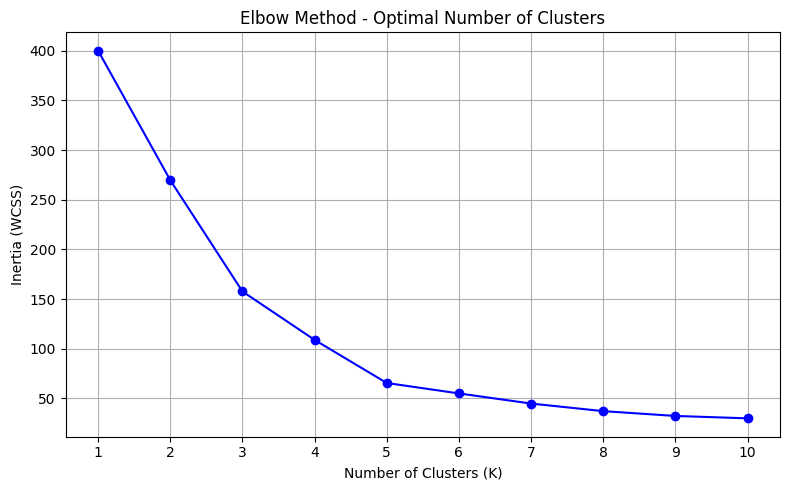

In [30]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X1_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='blue')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150)
plt.show()


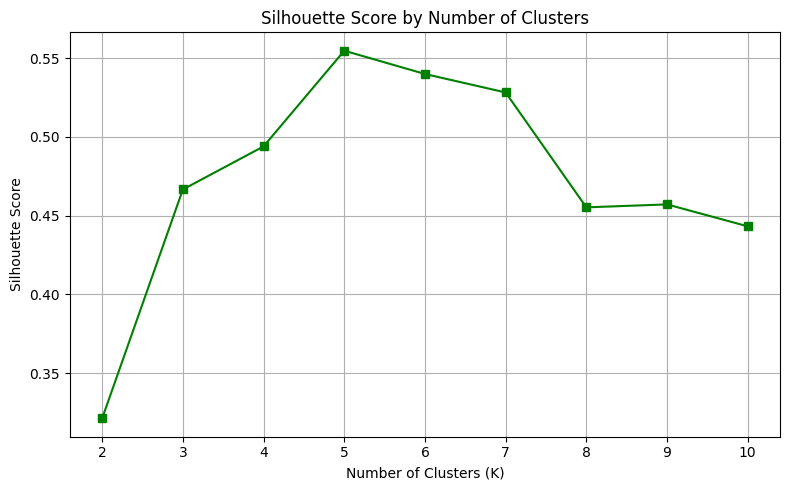

In [33]:
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X1_scaled)
    sil_scores.append(silhouette_score(X1_scaled, labels))

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='s', color='green')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=150)
plt.show()

In [35]:
best_k = range(2, 11)[sil_scores.index(max(sil_scores))]
print(f"Best K by Silhouette: {best_k}")

Best K by Silhouette: 5


#### Apply K-Means with K=5

In [36]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X1_scaled)

print("\nK-Means Cluster Counts:")
print(df['KMeans_Cluster'].value_counts().sort_index())


K-Means Cluster Counts:
KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


#### Visualize K-Means Clusters

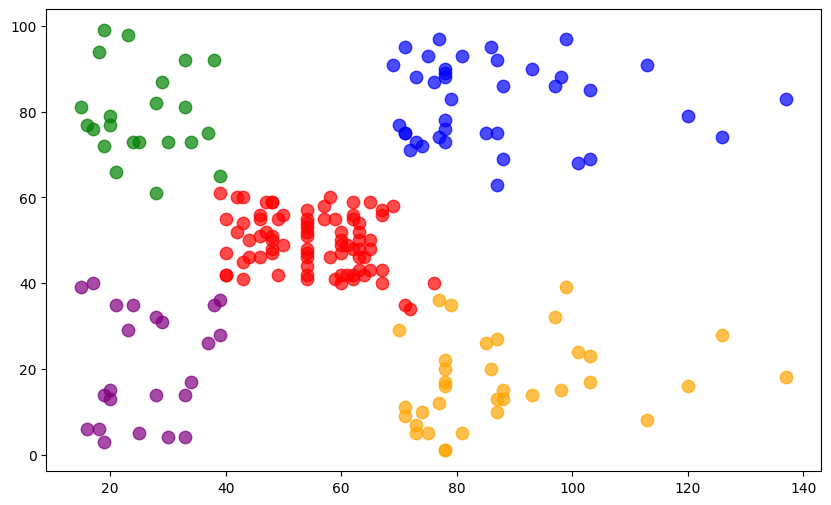

In [37]:
colors = ['red', 'blue', 'green', 'orange', 'purple']
cluster_names = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

plt.figure(figsize=(10, 6))
for i in range(5):
    subset = df[df['KMeans_Cluster'] == i]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                c=colors[i], label=cluster_names[i], s=80, alpha=0.7)

## Plot centroids

In [40]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

#### Dendrogram

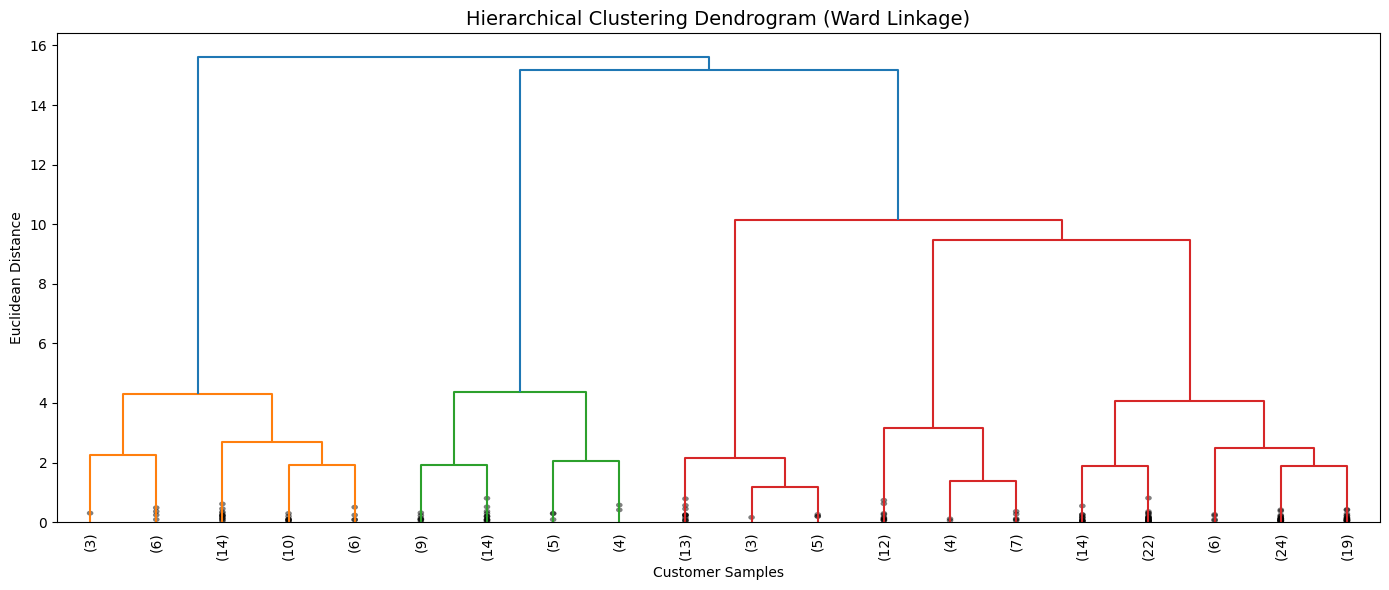

In [41]:
plt.figure(figsize=(14, 6))
linked = linkage(X1_scaled, method='ward')
dendrogram(linked,
           truncate_mode='lastp',
           p=20,
           leaf_rotation=90,
           leaf_font_size=10,
           show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14)
plt.xlabel('Customer Samples')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

#### Apply Agglomerative Clustering


Hierarchical Cluster Counts:
HC_Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64


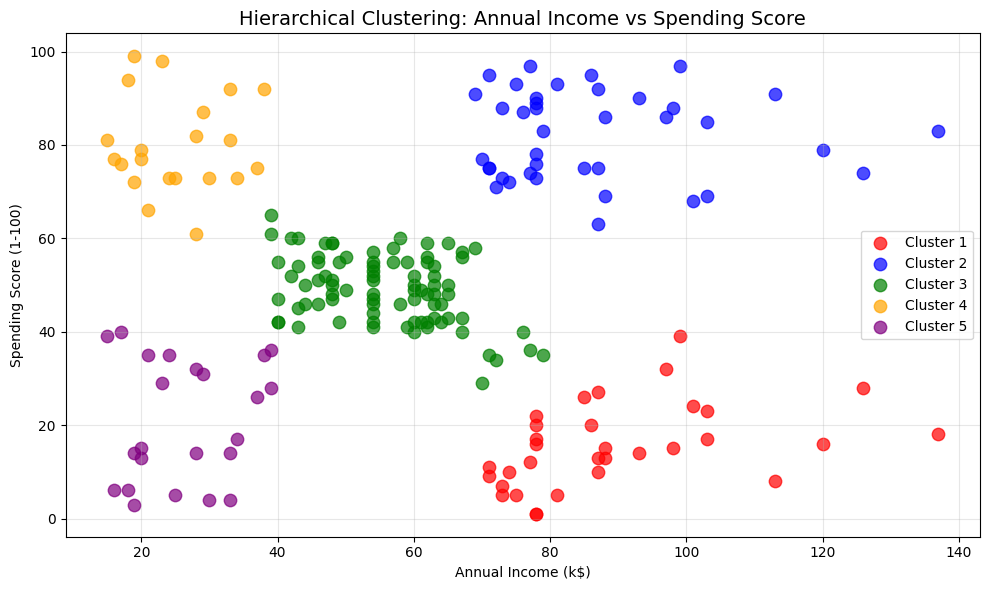

In [42]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['HC_Cluster'] = hc.fit_predict(X1_scaled)

print("\nHierarchical Cluster Counts:")
print(df['HC_Cluster'].value_counts().sort_index())

# --- 5C: Visualize HC Clusters ---
plt.figure(figsize=(10, 6))
for i in range(5):
    subset = df[df['HC_Cluster'] == i]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                c=colors[i], label=f'Cluster {i+1}', s=80, alpha=0.7)

plt.title('Hierarchical Clustering: Annual Income vs Spending Score', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hierarchical_clusters.png', dpi=150)
plt.show()

## DBSCAN Clustering

In [43]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

#### Find best epsilon using k-distance graph

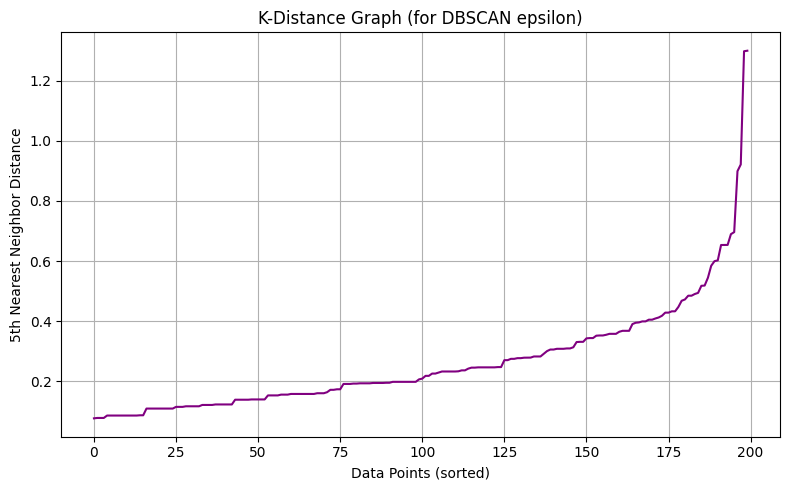

In [44]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X1_scaled)
distances, _ = nbrs.kneighbors(X1_scaled)
distances = np.sort(distances[:, 4])  # 4th nearest neighbor

plt.figure(figsize=(8, 5))
plt.plot(distances, color='purple')
plt.title('K-Distance Graph (for DBSCAN epsilon)')
plt.xlabel('Data Points (sorted)')
plt.ylabel('5th Nearest Neighbor Distance')
plt.grid(True)
plt.tight_layout()
plt.savefig('dbscan_epsilon.png', dpi=150)
plt.show()

#### Apply DBSCAN


DBSCAN Results:
Number of clusters: 2
Number of noise points (outliers): 8

Cluster Counts:
DBSCAN_Cluster
-1      8
 0    157
 1     35
Name: count, dtype: int64


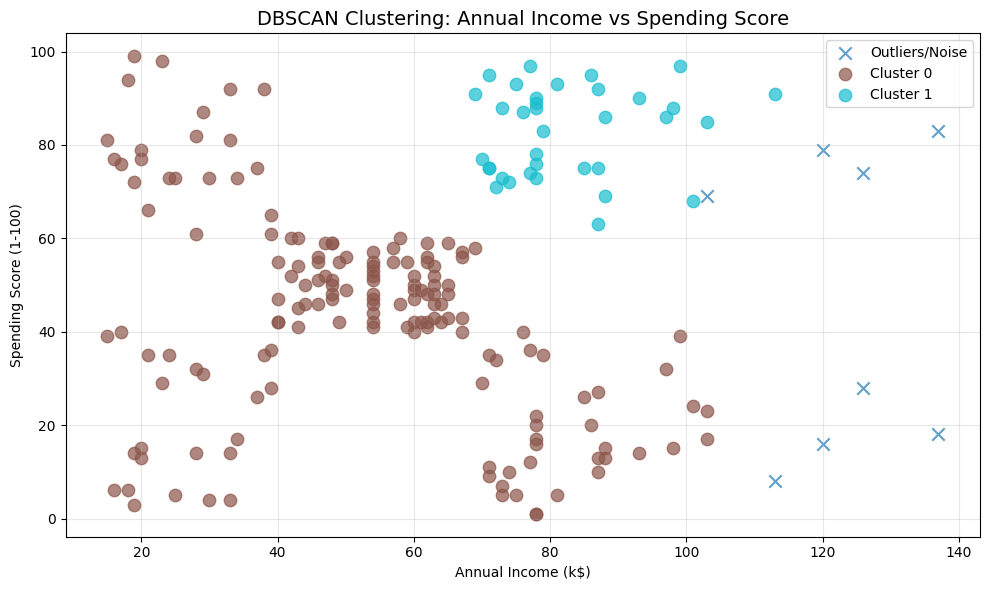

In [45]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X1_scaled)

n_clusters = len(set(df['DBSCAN_Cluster'])) - (1 if -1 in df['DBSCAN_Cluster'].values else 0)
n_noise = list(df['DBSCAN_Cluster']).count(-1)

print(f"\nDBSCAN Results:")
print(f"Number of clusters: {n_clusters}")
print(f"Number of noise points (outliers): {n_noise}")
print("\nCluster Counts:")
print(df['DBSCAN_Cluster'].value_counts().sort_index())

# --- 6C: Visualize DBSCAN ---
plt.figure(figsize=(10, 6))
unique_labels = sorted(df['DBSCAN_Cluster'].unique())
dbscan_colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, dbscan_colors):
    subset = df[df['DBSCAN_Cluster'] == label]
    name = f'Cluster {label}' if label != -1 else 'Outliers/Noise'
    marker = 'x' if label == -1 else 'o'
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                c=[color], label=name, s=80, marker=marker, alpha=0.7)

plt.title('DBSCAN Clustering: Annual Income vs Spending Score', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dbscan_clusters.png', dpi=150)
plt.show()

## Cluster Interpretation & Business Insights

#### Analyze K-Means clusters

In [46]:
cluster_summary = df.groupby('KMeans_Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean'),
    Female_Pct=('Gender_Encoded', lambda x: (x == 0).sum() / len(x) * 100)
).round(2)

print("=" * 65)
print("K-MEANS CLUSTER SUMMARY")
print("=" * 65)
print(cluster_summary)

K-MEANS CLUSTER SUMMARY
                Count  Avg_Age  Avg_Income  Avg_Spending  Female_Pct
KMeans_Cluster                                                      
0                  81    42.72       55.30         49.52       59.26
1                  39    32.69       86.54         82.13       53.85
2                  22    25.27       25.73         79.36       59.09
3                  35    41.11       88.20         17.11       45.71
4                  23    45.22       26.30         20.91       60.87


In [62]:
cluster_labels = {
    0: 'High Income, Low Spending (Careful Savers)',
    1: 'High Income, High Spending (Target Customers)',
    2: 'Average Income, Average Spending (Middle Class)',
    3: 'Low Income, High Spending (Impulsive Buyers)',
    4: 'Low Income, Low Spending (Budget Customers)'
}


print("\nBusiness Interpretation:")
for k, label in cluster_labels.items():
    print(f"  Cluster {k}: {label}")

print("\nMembership Card Strategy :")
print("Cluster 1 (High Income, High Spending) → Priority targets for premium membership")
print("Cluster 3 (Low Income, High Spending)  → Offer discount membership cards")
print("Cluster 0 (High Income, Low Spending)  → Incentivize with exclusive perks")
print("Cluster 2 (Middle)                     → Standard membership benefits")
print("Cluster 4 (Low, Low)                   → Free tier membership to attract")
print("DBSCAN Outliers (Cluster -1)           → VIP/Premium Elite Tier Cards (High-value erratic buyers)")


Business Interpretation:
  Cluster 0: High Income, Low Spending (Careful Savers)
  Cluster 1: High Income, High Spending (Target Customers)
  Cluster 2: Average Income, Average Spending (Middle Class)
  Cluster 3: Low Income, High Spending (Impulsive Buyers)
  Cluster 4: Low Income, Low Spending (Budget Customers)

Membership Card Strategy :
Cluster 1 (High Income, High Spending) → Priority targets for premium membership
Cluster 3 (Low Income, High Spending)  → Offer discount membership cards
Cluster 0 (High Income, Low Spending)  → Incentivize with exclusive perks
Cluster 2 (Middle)                     → Standard membership benefits
Cluster 4 (Low, Low)                   → Free tier membership to attract
DBSCAN Outliers (Cluster -1)           → VIP/Premium Elite Tier Cards (High-value erratic buyers)


##  Final Visualizations

#### Cluster Distribution Pie Chart

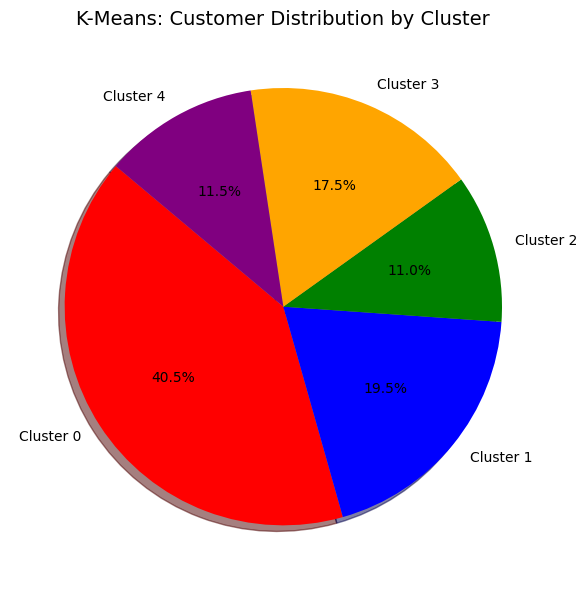

In [49]:
cluster_counts = df['KMeans_Cluster'].value_counts().sort_index()
labels_pie = [f'Cluster {i}' for i in cluster_counts.index]

plt.figure(figsize=(8, 6))
plt.pie(cluster_counts, labels=labels_pie, autopct='%1.1f%%',
        colors=colors, startangle=140, shadow=True)
plt.title('K-Means: Customer Distribution by Cluster', fontsize=14)
plt.tight_layout()
plt.savefig('cluster_pie.png', dpi=150)
plt.show()

#### Cluster Comparison Bar Charts

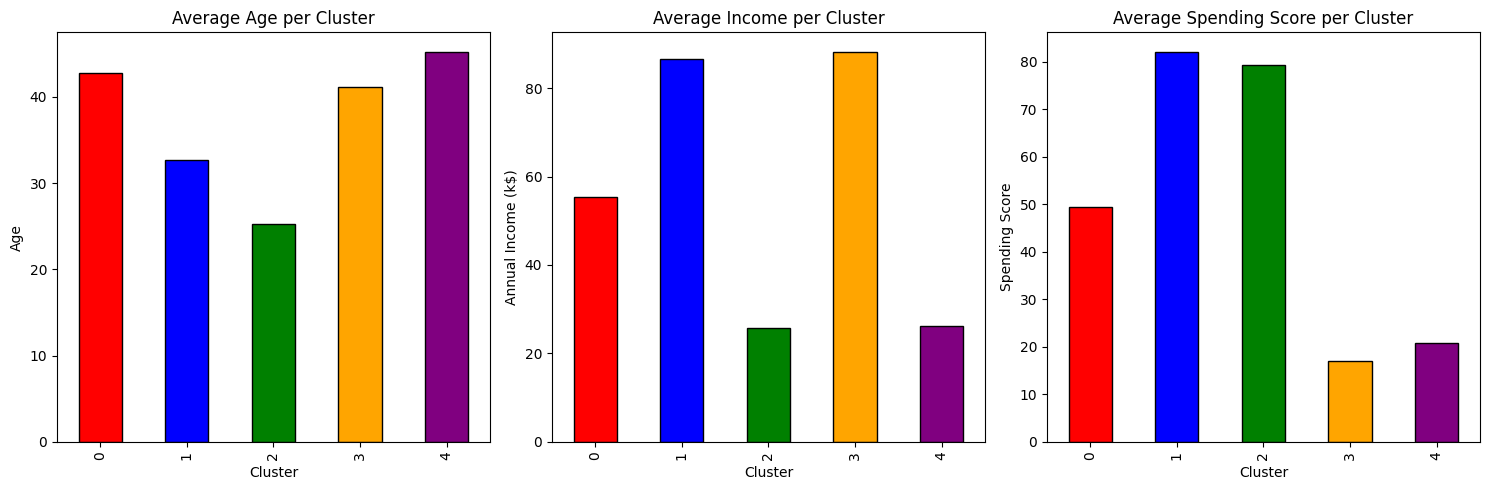

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cluster_summary['Avg_Age'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Average Age per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Age')

cluster_summary['Avg_Income'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Average Income per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Annual Income (k$)')

cluster_summary['Avg_Spending'].plot(kind='bar', ax=axes[2], color=colors, edgecolor='black')
axes[2].set_title('Average Spending Score per Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Spending Score')

plt.tight_layout()
plt.savefig('cluster_bar_comparison.png', dpi=150)
plt.show()


#### Gender by Cluster

<Figure size 800x500 with 0 Axes>

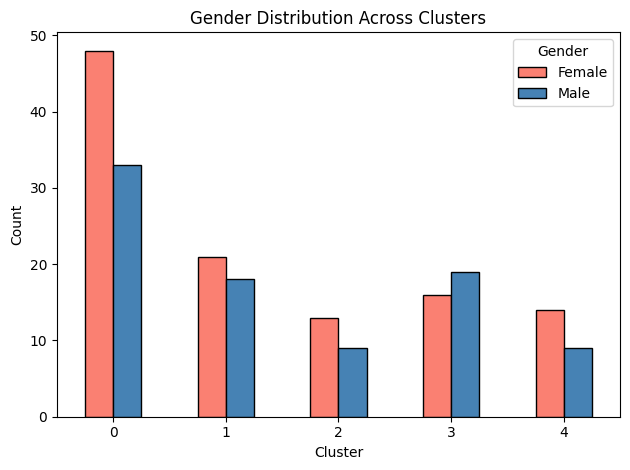

In [51]:
gender_cluster = df.groupby(['KMeans_Cluster', 'Gender']).size().unstack(fill_value=0)

plt.figure(figsize=(8, 5))
gender_cluster.plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.title('Gender Distribution Across Clusters')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('gender_cluster.png', dpi=150)
plt.show()

#### Correlation Heatmap

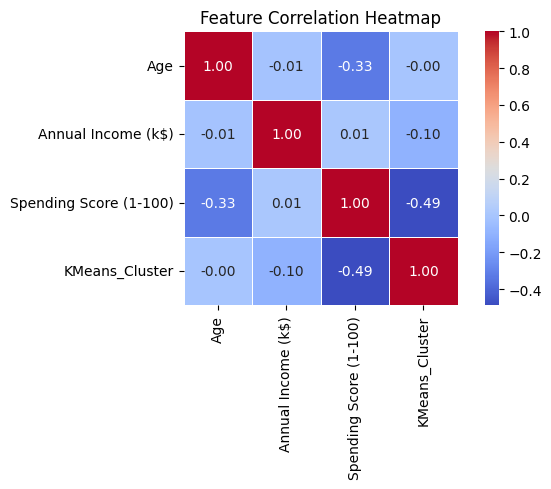

In [52]:
plt.figure(figsize=(7, 5))
corr = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'KMeans_Cluster']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()

#### Pairplot

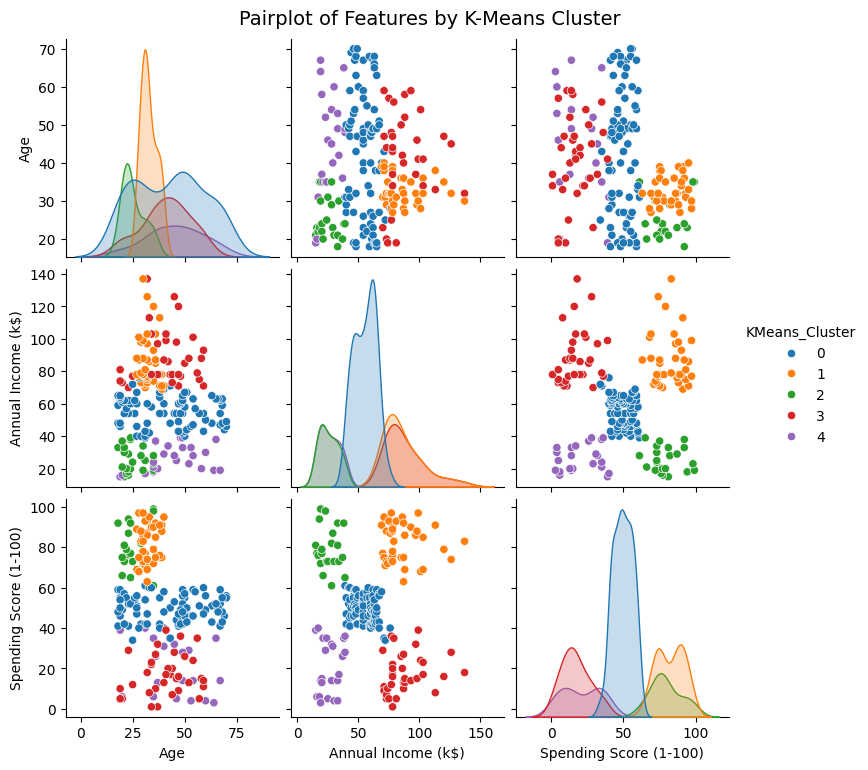


All visualizations saved


In [54]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'KMeans_Cluster']],
             hue='KMeans_Cluster', palette='tab10', diag_kind='kde')
plt.suptitle('Pairplot of Features by K-Means Cluster', y=1.02, fontsize=14)
plt.savefig('pairplot.png', dpi=150)
plt.show()

print("\nAll visualizations saved")

In [55]:
from sklearn.metrics import silhouette_score

In [56]:
# K- Mean Score
km_score = silhouette_score(X1_scaled, df['KMeans_Cluster'])

In [57]:
#  Hierarchical Score
hc_score = silhouette_score(X1_scaled, df['HC_Cluster'])

In [58]:
#  DBSCAN Score
db_score = silhouette_score(X1_scaled, df['DBSCAN_Cluster'])

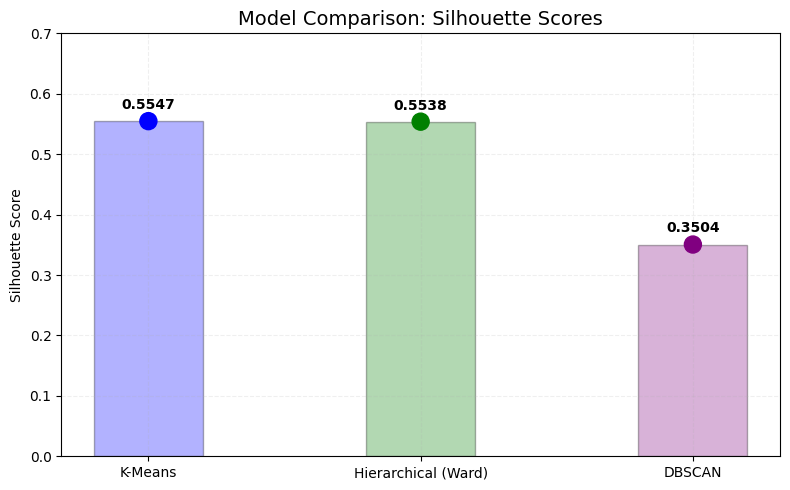

K-Means Silhouette Score: 0.5547
Hierarchical Silhouette Score: 0.5538
DBSCAN Silhouette Score: 0.3504


In [61]:
models = ['K-Means', 'Hierarchical (Ward)', 'DBSCAN']
scores = [km_score, hc_score, db_score]
plt.figure(figsize=(8, 5))
bars = plt.scatter(models, scores, color=['blue', 'green', 'purple'], s=150, zorder=3)
plt.bar(models, scores, color=['blue', 'green', 'purple'], alpha=0.3, edgecolor='black', width=0.4)

plt.title('Model Comparison: Silhouette Scores', fontsize=14)
plt.ylabel('Silhouette Score')
plt.ylim(0, 0.7)
plt.grid(True, alpha=0.2, linestyle='--')
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print(f"K-Means Silhouette Score: {km_score:.4f}")
print(f"Hierarchical Silhouette Score: {hc_score:.4f}")
print(f"DBSCAN Silhouette Score: {db_score:.4f}")

In [64]:
import plotly.express as px

In [74]:
kmeans_3d = KMeans(n_clusters=5, random_state=42, n_init=10)
df['KMeans_3D_Cluster'] = kmeans_3d.fit_predict(X3_scaled)

fig = px.scatter_3d(df, 
                    x='Age', 
                    y='Annual Income (k$)', 
                    z='Spending Score (1-100)',
                    color='KMeans_3D_Cluster',
                    title='3D Customer Segmentation (Age vs Income vs Spending Score)',
                    opacity=0.8,
                    color_continuous_scale=px.colors.sequential.Viridis)


fig.write_html("customer_segments_3d.html")
fig.show()